In [1]:
import pandas as pd
import numpy as np

In [2]:
from google.colab import files
uploaded = files.upload()

Saving PhiUSIIL_Phishing_URL_Dataset.csv to PhiUSIIL_Phishing_URL_Dataset.csv


In [4]:
import pandas as pd
df = pd.read_csv("PhiUSIIL_Phishing_URL_Dataset.csv")
print(df.shape)

(235795, 56)


In [6]:
df.columns

Index(['FILENAME', 'URL', 'URLLength', 'Domain', 'DomainLength', 'IsDomainIP',
       'TLD', 'URLSimilarityIndex', 'CharContinuationRate',
       'TLDLegitimateProb', 'URLCharProb', 'TLDLength', 'NoOfSubDomain',
       'HasObfuscation', 'NoOfObfuscatedChar', 'ObfuscationRatio',
       'NoOfLettersInURL', 'LetterRatioInURL', 'NoOfDegitsInURL',
       'DegitRatioInURL', 'NoOfEqualsInURL', 'NoOfQMarkInURL',
       'NoOfAmpersandInURL', 'NoOfOtherSpecialCharsInURL',
       'SpacialCharRatioInURL', 'IsHTTPS', 'LineOfCode', 'LargestLineLength',
       'HasTitle', 'Title', 'DomainTitleMatchScore', 'URLTitleMatchScore',
       'HasFavicon', 'Robots', 'IsResponsive', 'NoOfURLRedirect',
       'NoOfSelfRedirect', 'HasDescription', 'NoOfPopup', 'NoOfiFrame',
       'HasExternalFormSubmit', 'HasSocialNet', 'HasSubmitButton',
       'HasHiddenFields', 'HasPasswordField', 'Bank', 'Pay', 'Crypto',
       'HasCopyrightInfo', 'NoOfImage', 'NoOfCSS', 'NoOfJS', 'NoOfSelfRef',
       'NoOfEmptyRef', 'NoOf

In [9]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

X = df.drop(['label','FILENAME','URL','Domain','Title'],axis=1, errors = 'ignore')

# Convert categorical 'TLD' column to numerical using one-hot encoding
X = pd.get_dummies(X, columns=['TLD'], drop_first=True)

Y = df['label']

X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=42)

model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, Y_train)

Y_pred = model.predict(X_test)
accuracy = accuracy_score(Y_test, Y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.9999575902796921


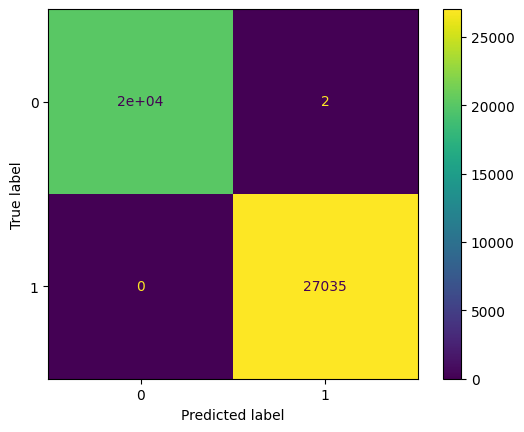

In [10]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(Y_test, Y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)
disp.plot()
plt.show()

In [11]:
import pandas as pd
feature_importance = pd.DataFrame({'Feature': X.columns, 'Importance': model.feature_importances_})
feature_importance = feature_importance.sort_values(by='Importance', ascending=False)
print(feature_importance)

                Feature  Importance
3    URLSimilarityIndex    0.094060
46               NoOfJS    0.085778
49      NoOfExternalRef    0.082692
44            NoOfImage    0.082338
22           LineOfCode    0.070872
..                  ...         ...
372            TLD_gift    0.000000
373           TLD_gifts    0.000000
374           TLD_gives    0.000000
375              TLD_gl    0.000000
508         TLD_monster    0.000000

[744 rows x 2 columns]


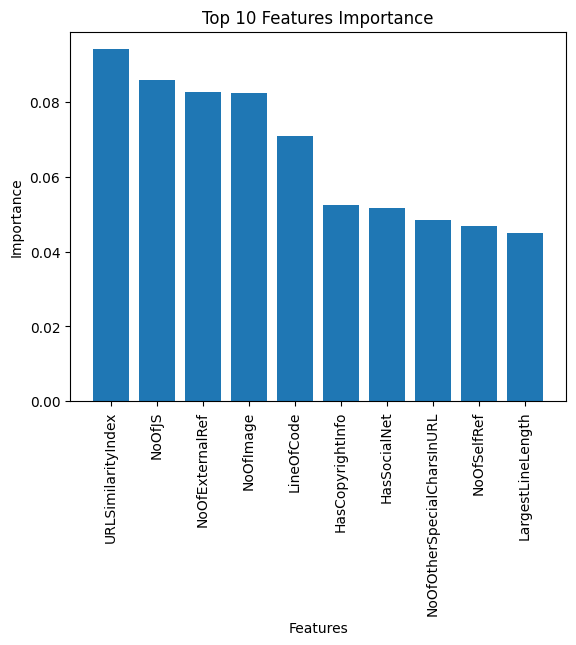

In [12]:
import matplotlib.pyplot as plt
top10_features = feature_importance.head(10)
plt.bar(top10_features['Feature'], top10_features['Importance'])
plt.xlabel('Features')
plt.ylabel('Importance')
plt.title('Top 10 Features Importance')
plt.xticks(rotation=90)
plt.show()

In [14]:
from sklearn.metrics import classification_report
print(classification_report(Y_test, Y_pred))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00     20124
           1       1.00      1.00      1.00     27035

    accuracy                           1.00     47159
   macro avg       1.00      1.00      1.00     47159
weighted avg       1.00      1.00      1.00     47159



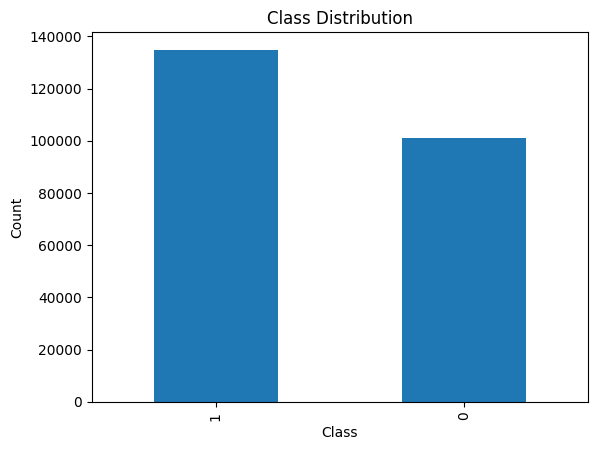

In [15]:
df['label'].value_counts().plot(kind='bar', title='Class Distribution')
plt.xlabel('Class')
plt.ylabel('Count')
plt.show()

In [16]:
import joblib
joblib.dump(model, 'phishing_model.pkl')
print("Model saved as phishing_model.pkl")


Model saved as phishing_model.pkl


In [17]:
print(feature_importance.head(10))


                       Feature  Importance
3           URLSimilarityIndex    0.094060
46                      NoOfJS    0.085778
49             NoOfExternalRef    0.082692
44                   NoOfImage    0.082338
22                  LineOfCode    0.070872
43            HasCopyrightInfo    0.052498
36                HasSocialNet    0.051743
19  NoOfOtherSpecialCharsInURL    0.048367
47                 NoOfSelfRef    0.046903
23           LargestLineLength    0.044985
